# EEG GNN — Parameter Sweep & Evaluation

This notebook runs a structured sweep over the key GNN hyperparameters
and feature/graph configurations, then visualises results.

**Pipeline files required in the same directory:**
- `features.py`, `graph.py`, `models.py`, `dataset.py`, `train.py`, `pipeline.py`

**Expected data format (from your existing preprocessing pipeline):**
```python
total_data[subject_id] = {'data': (N, C, T), 'labels': (N,)}
test_data[subject_id]  = {'data': (N, C, T), 'labels': (N,)}
```

In [1]:
# ── Imports ────────────────────────────────────────────────────────────────
import sys, os, json, itertools, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import mne

mne.set_log_level('ERROR')   # silence MNE

warnings.filterwarnings("ignore")  # silence warnings
warnings.filterwarnings('ignore')

# Add pipeline directory to path (adjust if needed)
sys.path.insert(0, os.path.abspath('.'))

from pipeline import GNNConfig, run_all_subjects

print(f"PyTorch  : {torch.__version__}")
print(f"Device   : {'cuda' if torch.cuda.is_available() else 'cpu'}")
DEVICE = 'mps' if torch.backends.mps.is_available() else 'cpu'
DEVICE = 'cpu'
print(DEVICE)


PyTorch  : 2.2.2
Device   : cpu
cpu


## 1. Load data
Plug in your existing preprocessing pipeline here.

In [2]:
latest_channel_list = [
    # Left sensorimotor area channels
    'E29', 'E30', 'E35', 'E36', 'E41', 'E42',
    # Right sensorimotor area channels
    'E103', 'E104', 'E109', 'E110', 'E115', 'E116',
    # Mid-parietal & bilateral parietal
    'E62', 'E67', 'E72', 'E77'
 ]

new_latest = [
        'E24', 'E124', 'E36', 'E104', 'E47', 'E52', 'E60', 'E67', 'E72', 'E77',
        'E85', 'E92', 'E98', 'E62', 'E70', 'E75', 'E83', 'E58', 'E96', 'E90',
        'E65', 'E69', 'E74', 'E82', 'E89', 'E1', 'E32', 'E14', 'E21','E9','E22','E122','E33','E108','E100','E57'
    ]

bad_channels = ['E17', 'E38', 'E94', 'E113', 'E119', 'E121', 'E125', 'E128', 'E73', 'E81', 'E88', 'E43', 'E44', 'E120', 'E114','E127', 'E126',
                 'E68', 'E23', 'E3','E49','E48', "E8", "E25",
     "E56", "E63", "E99", "E107"]


                 
#bad_channels = ['E48', 'E119', 'E49', 'E113', 'E94', 'E68', 'E23', 'E3', 'E126', 'E127']



#label_dict = {'OBBA': 0, 'OBBY': 1, 'OBDO': 2, 'OBMO': 3, 'OBSI':4}
# banana, dog, sitar
directions = ['IMBA', 'IMBY', 'IMSI']

#directions = ['OBBA', 'OBBY', 'OBDO', 'OBDO','OBSI']  # Left, Right, Up, Down

In [3]:
label_dict = {'IMBA': 0,'IMBY': 1,'IMSI':2 }
channel_tuple = (new_latest, bad_channels)


In [4]:
class preprocessing_pipeline:
    def __init__(self, filename, *channel_tuple, 
                 l_freq=1.0, h_freq=40.0, notch_freq=50.0, fs=500.0, time_window=0.5,
                 apply_ica=True, remove_muscle=False,
                 eog_vertical_chs=('E14', 'E21'), eog_horizontal_chs=('E1', 'E32')):
        
        self.filename = filename
        self.l_freq = l_freq
        self.h_freq = h_freq
        self.notch_freq = notch_freq
        self.time_window = time_window
        self.fs = fs
        self.active_channels = channel_tuple[0]
        self.bad_channels = channel_tuple[1]
        self.apply_ica = apply_ica
        self.remove_muscle = remove_muscle
        self.eog_vertical_chs = list(eog_vertical_chs)
        self.eog_horizontal_chs = list(eog_horizontal_chs)
        self.ica = None  # Store for inspection later

        self.raw = self.file_process()
        self.annotations = self.raw.annotations

    def file_process(self):
        raw = mne.io.read_raw_egi(self.filename, preload=True)
        
        if 'VREF' in raw.ch_names:
            raw.drop_channels(['VREF'])

        raw.pick('eeg')
        raw.pick(self.active_channels)

        # if self.bad_channels:
        #     raw.drop_channels([ch for ch in self.bad_channels if ch in raw.ch_names])
  

        # Filter BEFORE ICA (ICA needs broadband signal to detect artifacts)
        # Use 1Hz high-pass for ICA fitting even if analysis band is higher
        raw.notch_filter(freqs=self.notch_freq, picks='eeg', verbose=False, pad='edge')
        raw.filter(l_freq=1.0, h_freq=self.h_freq, picks='eeg', verbose=False, pad='edge')

        if self.apply_ica:
            raw = self._run_ica(raw)

        # Apply analysis band-pass AFTER ICA (if l_freq > 1.0)
        if self.l_freq > 1.0:
            raw.filter(l_freq=self.l_freq, h_freq=None, picks='eeg', verbose=False, pad='edge')

        # Average reference AFTER ICA
        raw.set_eeg_reference('average', projection=False)

        return raw

    def _run_ica(self, raw):
        """
        Adds EOG proxies, fits ICA, removes artifact components, 
        then strips proxy channels. Returns cleaned raw (EEG only).
        """
        # --- 1. Add EOG proxy channels temporarily ---
        eog_proxies_added = []

        vert_chs = [ch for ch in self.eog_vertical_chs if ch in raw.ch_names]
        if vert_chs:
            proxy = raw.copy().pick_channels(vert_chs).get_data().mean(axis=0)
            info = mne.create_info(['EOG_vertical'], raw.info['sfreq'], ch_types=['eog'])
            raw.add_channels([mne.io.RawArray(proxy[np.newaxis, :], info)], force_update_info=True)
            eog_proxies_added.append('EOG_vertical')

        horiz_chs = [ch for ch in self.eog_horizontal_chs if ch in raw.ch_names]
        if horiz_chs:
            proxy = raw.copy().pick_channels(horiz_chs).get_data().mean(axis=0)
            info = mne.create_info(['EOG_horizontal'], raw.info['sfreq'], ch_types=['eog'])
            raw.add_channels([mne.io.RawArray(proxy[np.newaxis, :], info)], force_update_info=True)
            eog_proxies_added.append('EOG_horizontal')

        # --- 2. Fit ICA on EEG channels only (not proxies) ---
        eeg_only = raw.copy().pick_types(eeg=True)
        rank = mne.compute_rank(eeg_only, tol=1e-6, tol_kind='relative')
        n_components = min(25, rank['eeg'])

        print(f"\n🔧 Fitting ICA with {n_components} components on {len(eeg_only.ch_names)} EEG channels...")
        ica = mne.preprocessing.ICA(
            n_components=n_components, 
            random_state=42,
            method='fastica', 
            max_iter=200
        )
        ica.fit(eeg_only)

        # --- 3. Detect bad components ---
        bad_components = []

        if 'EOG_vertical' in raw.ch_names:
            idx, _ = ica.find_bads_eog(raw, ch_name='EOG_vertical', threshold=2.5)
            print(f"  Vertical EOG (blinks): {idx}")
            bad_components.extend(idx)

        if 'EOG_horizontal' in raw.ch_names:
            idx, _ = ica.find_bads_eog(raw, ch_name='EOG_horizontal', threshold=2.5)
            print(f"  Horizontal EOG (saccades): {idx}")
            bad_components.extend(idx)

        if self.remove_muscle:
            try:
                idx, _ = ica.find_bads_muscle(raw, threshold=0.2)
                print(f"  Muscle artifacts: {idx}")
                bad_components.extend(idx)
            except Exception as e:
                print(f"  Muscle detection skipped: {e}")

        ica.exclude = sorted(set(bad_components))
        print(f"\n  Excluding {len(ica.exclude)}/{n_components} components: {ica.exclude}")
        self.ica = ica  # Save for later inspection

        # --- 4. Apply ICA to EEG-only copy, then re-attach annotations ---
        # Apply only to EEG channels (proxy channels are NOT passed to apply)
        raw_eeg_clean = ica.apply(eeg_only)  # operates on the eeg-only copy
        
        # Restore annotations (crop/copy loses them)
        raw_eeg_clean.set_annotations(raw.annotations)

        print(f"  ✅ ICA done. Final channel count: {len(raw_eeg_clean.ch_names)}")
        return raw_eeg_clean  # Pure EEG, proxies never re-added

    def baseline_stats(self):
        baseline_data = None
        for start_m, end_m in [('BLCS', 'BLCE'), ('BSST', 'BSEN')]:
            try:
                tmin = next(a['onset'] for a in self.annotations if a['description'] == start_m)
                tmax = next(a['onset'] for a in self.annotations if a['description'] == end_m)
                baseline_data = self.raw.copy().crop(tmin=tmin, tmax=tmax).get_data(picks='eeg')
                print(f"✅ Baseline: {start_m}/{end_m}")
                break
            except StopIteration:
                continue

        if baseline_data is None:
            print("⚠️  No baseline markers — using full recording.")
            baseline_data = self.raw.get_data(picks='eeg')

        mean = np.mean(baseline_data, axis=1, keepdims=True)
        std  = np.std(baseline_data,  axis=1, keepdims=True)
        std[std == 0] = 1.0
        return mean, std


    def extracting_data(self, start_offset=0.4, end_offset=0.2, overlap_factor=0.5, normalize = True):
            #base_mean, base_std = self.baseline_stats()
            base_mean, base_std = 0,1
            #classes = ['BA', 'BY', 'DO', 'MO', 'SI']
            classes = ['BA', 'BY', 'SI']
            # Changed from flat list to a dictionary grouped by class
            trial_groups = {cls: [] for cls in classes} 

            for cls in classes:
                starts = [ann['onset'] for ann in self.annotations if ann['description'] == f'IS{cls}']
                ends   = [ann['onset'] for ann in self.annotations if ann['description'] == f'IE{cls}']

                for start, end in zip(starts, ends):
                    segment = self.raw.copy().crop(tmin=start+start_offset, tmax=end+end_offset)
                    data = segment.get_data(picks='eeg').astype(np.float32)

                    if normalize is not None:
                        data = (data - base_mean)/base_std

                    window_samples = int(self.time_window * self.fs)
                    step_samples = int(window_samples * (1-overlap_factor))
                    
                    total_samples = data.shape[1]
                    this_trial_windows = []
                    
                    for start_pt in range(0, total_samples - window_samples + 1, step_samples):
                        chunk = data[:, start_pt:start_pt + window_samples]
                        this_trial_windows.append(chunk)

                    if this_trial_windows:
                        # Store as a tuple: (Array of Windows, Label)
                        X_windows = np.stack(this_trial_windows, axis=0)
                        y_windows = np.full(X_windows.shape[0], label_dict[f'IM{cls}'])
                        trial_groups[cls].append((X_windows, y_windows))

            return trial_groups


In [5]:
import os

# Point this to the parent "Data" directory
base_dir = "/Users/kavinfidel/Desktop/GNN+CNS+Hopf/CNS_Lab/VM_EEG/data_2"
#base_dir = "/home/kavinfidel/projects/VM_EEG/Data"
subject_dirs = {}

# 1. Get all items in the Data folder
# 2. Filter for directories that start with 'S'
sub_folders = [f for f in os.listdir(base_dir) if os.path.isdir(os.path.join(base_dir, f)) and f.startswith('S')]

for folder in sub_folders:
    folder_path = os.path.join(base_dir, folder)
    files = []
    
    # List all .mff files within each subject's folder
    for file_name in os.listdir(folder_path):
        if not file_name.startswith('.') and file_name.endswith('.mff'):
            files.append(file_name)
    
    # Using the actual folder name (e.g., 'S1', 'S113') as the key
    subject_dirs[folder] = files

# Verification
print(f"Found {len(subject_dirs)} subjects.")
print("Subjects identified:", list(subject_dirs.keys()))

Found 9 subjects.
Subjects identified: ['S116', 'S118', 'S119', 'S117', 'S2_', 'S1_', 'S115', 'S113', 'S114']


In [6]:

del subject_dirs['S113']
del subject_dirs['S114']
del subject_dirs['S117']
del subject_dirs['S2_']

del subject_dirs['S116']

In [7]:
del subject_dirs['S119']
del subject_dirs['S115']


In [8]:
del subject_dirs['S118']

In [9]:
print(subject_dirs.keys())

dict_keys(['S1_'])


In [10]:
total_data = {}
test_data = {}


for subject, files in subject_dirs.items(): # subject is id, files are the all the files associated with a subject
    print(f"Processing {subject}")
    
    total_data[f"{subject}"] = {} #?
    test_data[f"{subject}"] = {}
    signals = [] #?
    labels = []#?
    signals_test = []
    labels_test = []
    k = 0
    for file_name in files:
        k +=1
        file_path = os.path.join(base_dir,subject, file_name) # grabbing file path, the mff file?
        
        if not file_name.endswith('.mff'):
            print(f"Skipping non-raw file: {file_name}")
            continue
        
        required_parts = ["signal1.bin", "info1.xml"]
        missing_parts = [p for p in required_parts if not os.path.exists(os.path.join(file_path, p))] # wha tis happenign here?
        if missing_parts:
            print(f"Skipping {file_name} due to parts being missing")
            continue
        
        print(f"File is intact: {file_name}\n Beginning extraction...")
        

        try:
            processor = preprocessing_pipeline(file_path, *channel_tuple)
            # trial_data is now a dict: {'BA': [(win, lab), (win, lab), (win, lab)], ...}
            trial_data = processor.extracting_data()

            if k == 2:
                print(f"Splitting Block {k} into Training and Test...")
                for cls, trials in trial_data.items():
                    # 1. Take the LAST trial (image event) for Testing
                    test_trial_x, test_trial_y = trials.pop() 
                    signals_test.append(test_trial_x)
                    labels_test.append(test_trial_y)
                    
                    # 2. Put the REMAINING trials from this block into Training
                    for x, y in trials:
                        signals.append(x)
                        labels.append(y)
            else:
                # For Block 1 or 3, just put everything into Training
                for cls, trials in trial_data.items():
                    for x, y in trials:
                        signals.append(x)
                        labels.append(y)

        except Exception as e:
            print(f"Error processing {file_name}: {e}")
            continue

    
    total_data[f"{subject}"]['data'] = np.concatenate(signals, axis=0)
    total_data[f"{subject}"]['labels'] = np.concatenate(labels, axis=0)   
    
    test_data[f"{subject}"]['data'] = np.concatenate(signals_test, axis=0)
    test_data[f"{subject}"]['labels'] = np.concatenate(labels_test, axis=0)  

    

Processing S1_
File is intact: VI_S1_S2_B3__20260404_030014.mff
 Beginning extraction...

🔧 Fitting ICA with 25 components on 36 EEG channels...
  Vertical EOG (blinks): [0, 4]
  Horizontal EOG (saccades): [0, 4, 7]

  Excluding 3/25 components: [0, 4, 7]
  ✅ ICA done. Final channel count: 36
File is intact: VI_S1_S2_B2__20260404_025101.mff
 Beginning extraction...

🔧 Fitting ICA with 25 components on 36 EEG channels...
  Vertical EOG (blinks): [0, 1]
  Horizontal EOG (saccades): [0, 1]

  Excluding 2/25 components: [0, 1]
  ✅ ICA done. Final channel count: 36
Splitting Block 2 into Training and Test...
File is intact: VI_S1_S1_B1_20251110_120112.mff
 Beginning extraction...

🔧 Fitting ICA with 25 components on 36 EEG channels...
  Vertical EOG (blinks): [0]
  Horizontal EOG (saccades): [0]

  Excluding 1/25 components: [0]
  ✅ ICA done. Final channel count: 36
File is intact: VI_S1_S1_B2_20251110_121030.mff
 Beginning extraction...

🔧 Fitting ICA with 25 components on 36 EEG channels.

## 2. Sanity check — single subject, default config

In [11]:
total_data.keys()

dict_keys(['S1_'])

## 3. Parameter sweep

Grid sweep over:
| Axis | Values |
|------|--------|
| Feature type | `classical`, `autoencoder` |
| Adjacency method | `plv`, `pearson` |
| GNN architecture | `gcn`, `graphsage`, `gat` |
| PLV/edge threshold | `0.2`, `0.3`, `0.5` |
| Hidden dim | `32`, `64` |

Runs **train→test** mode for all subjects; results collected into a DataFrame.

In [12]:
from pipeline import run_subject_train_test

In [12]:
# ── Sweep grid ─────────────────────────────────────────────────────────────
SWEEP_GRID = dict(
    feature_type  = ['autoencoder'],
    adj_method    = ['plv'],
    arch          = ['gcn'],
    adj_threshold = [0.15],
    hidden_dim    = [64],
)

# Fixed hyperparameters for all sweep runs
SWEEP_FIXED = dict(
    n_layers      = 2,
    dropout       = 0.2,
    epochs        = 1000,
    patience      = 100,
    batch_size    = 64,
    lr            = 1e-4,
    weight_decay  = 1e-4,
    fs            = 500,
    device        = 'cpu',
    verbose       = True,
    ae_latent_dim = 16,
    ae_epochs     = 100,
)

keys   = list(SWEEP_GRID.keys())
combos = list(itertools.product(*SWEEP_GRID.values()))
print(f"Total sweep combinations: {len(combos)}")
print(f"Total runs (× subjects): {len(combos) * len(total_data)}")

Total sweep combinations: 1
Total runs (× subjects): 1


In [13]:
N_CLASSES = 3

In [14]:
# ── Run sweep ──────────────────────────────────────────────────────────────
# ⚠️  This will take a while. Reduce SWEEP_GRID or use 'classical' only
#    for a faster first run.

sweep_results = []

for i, combo in enumerate(combos):
    params = dict(zip(keys, combo))
    cfg = GNNConfig(**params, **SWEEP_FIXED)

    label = ' | '.join(f'{k}={v}' for k, v in params.items())
    print(f"\n[{i+1:03d}/{len(combos)}] {label}")

    try:
        results = run_all_subjects(
            total_data=total_data,
            test_data=test_data,
            cfg=cfg,
            n_classes=N_CLASSES,
            mode='train_test',
        )

        for subj, m in results.items():
            if subj == '__summary__':
                continue
            row = {**params,
                   'subject':          subj,
                   'accuracy':         m.get('accuracy', np.nan),
                   'balanced_accuracy':m.get('balanced_accuracy', np.nan),
                   'kappa':            m.get('kappa', np.nan),
                   'f1_macro':         m.get('f1_macro', np.nan)}
            sweep_results.append(row)

    except Exception as e:
        print(f"  ⚠️  Error: {e}")
        continue

df = pd.DataFrame(sweep_results)
print(f"\n✅ Sweep done. Total rows: {len(df)}")
df.head()


[001/1] feature_type=autoencoder | adj_method=plv | arch=gcn | adj_threshold=0.15 | hidden_dim=64

──────────────────────────────────────────────────
Subject S1_ | Train→Test mode
  Training channel autoencoder …
  AE Epoch  10/100 | Loss: 0.273076
  AE Epoch  20/100 | Loss: 0.241998
  AE Epoch  30/100 | Loss: 0.231915
  AE Epoch  40/100 | Loss: 0.226079
  AE Epoch  50/100 | Loss: 0.221901
  AE Epoch  60/100 | Loss: 0.218288
  AE Epoch  70/100 | Loss: 0.216202
  AE Epoch  80/100 | Loss: 0.214559
  AE Epoch  90/100 | Loss: 0.213638
  AE Epoch 100/100 | Loss: 0.213184
  Extracting AE latent features …
  Extracting AE latent features …
  Epoch  10 | val_loss=1.2734 | val_acc=0.319
  Epoch  20 | val_loss=1.2192 | val_acc=0.264
  Epoch  30 | val_loss=1.1968 | val_acc=0.292
  Epoch  40 | val_loss=1.1873 | val_acc=0.306
  Epoch  50 | val_loss=1.1933 | val_acc=0.292
  Epoch  60 | val_loss=1.1843 | val_acc=0.319
  Epoch  70 | val_loss=1.2089 | val_acc=0.319
  Epoch  80 | val_loss=1.2187 | val_

,feature_type,adj_method,arch,adj_threshold,hidden_dim,subject,accuracy,balanced_accuracy,kappa,f1_macro
0,autoencoder,plv,gcn,0.15,64,S1_,0.333333,0.333333,0.0,0.166667


In [15]:
# Save to CSV for later analysis
df.to_csv('sweep_results.csv', index=False)
print("Saved → sweep_results.csv")

Saved → sweep_results.csv


## 4. Visualisation

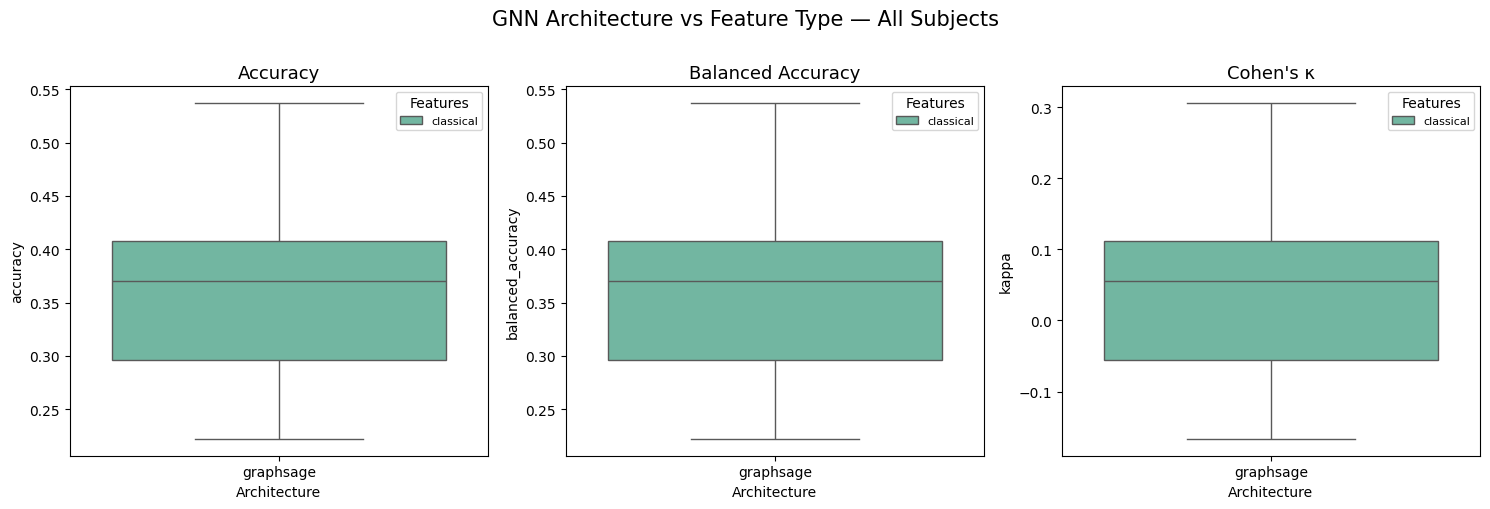

In [ ]:
# ── 4a. Overall accuracy distribution per architecture ─────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
metrics_to_plot = ['accuracy', 'balanced_accuracy', 'kappa']
titles = ['Accuracy', 'Balanced Accuracy', "Cohen's κ"]

for ax, metric, title in zip(axes, metrics_to_plot, titles):
    sns.boxplot(data=df, x='arch', y=metric, hue='feature_type',
                palette='Set2', ax=ax)
    ax.set_title(title, fontsize=13)
    ax.set_xlabel('Architecture')
    ax.set_ylabel(metric)
    ax.legend(title='Features', fontsize=8)

plt.suptitle('GNN Architecture vs Feature Type — All Subjects', fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig('arch_vs_features.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ── 4b. PLV vs Pearson per architecture ────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=df, x='arch', y='accuracy', hue='adj_method',
            palette='coolwarm', capsize=0.1, ax=ax)
ax.set_title('PLV vs Pearson Adjacency — Mean Accuracy per Architecture')
ax.set_xlabel('Architecture')
ax.set_ylabel('Test Accuracy')
plt.tight_layout()
plt.savefig('plv_vs_pearson.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ── 4c. Threshold sensitivity ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
sns.lineplot(data=df, x='adj_threshold', y='accuracy', hue='arch',
             style='adj_method', markers=True, dashes=True, ax=ax)
ax.set_title('Accuracy vs Edge Threshold')
ax.set_xlabel('Adjacency Threshold τ')
ax.set_ylabel('Test Accuracy')
plt.tight_layout()
plt.savefig('threshold_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ── 4d. Per-subject heatmap — best config per subject ─────────────────────
best_per_subject = (
    df.groupby(['subject', 'arch', 'feature_type', 'adj_method'])
      ['accuracy'].mean()
      .reset_index()
)

pivot = best_per_subject.pivot_table(
    index='subject',
    columns=['arch', 'feature_type'],
    values='accuracy',
    aggfunc='max',
)

fig, ax = plt.subplots(figsize=(12, max(4, len(total_data))))
sns.heatmap(pivot, annot=True, fmt='.3f', cmap='YlGnBu',
            linewidths=0.5, ax=ax, vmin=0.4, vmax=1.0)
ax.set_title('Best Test Accuracy per Subject × (Arch, Feature) Combination')
plt.tight_layout()
plt.savefig('subject_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ── 4e. Summary table — top configs ────────────────────────────────────────
summary = (
    df.groupby(['feature_type', 'adj_method', 'arch', 'adj_threshold', 'hidden_dim'])
      [['accuracy', 'balanced_accuracy', 'kappa', 'f1_macro']]
      .agg(['mean', 'std'])
      .reset_index()
)
summary.columns = [' '.join(c).strip() for c in summary.columns]
summary = summary.sort_values('accuracy mean', ascending=False)

print("Top 10 configurations (averaged across subjects):")
display(summary.head(10).to_string(index=False))

## 5. Best config — per-subject confusion matrices

In [ ]:
# Re-run the single best config and visualise confusion matrices
best_row = summary.iloc[0]

best_cfg = GNNConfig(
    feature_type  = best_row['feature_type'],
    adj_method    = best_row['adj_method'],
    arch          = best_row['arch'],
    adj_threshold = best_row['adj_threshold'],
    hidden_dim    = int(best_row['hidden_dim']),
    **SWEEP_FIXED,
    verbose       = True,
)

print("Best config:")
print(f"  feature_type={best_cfg.feature_type} | adj={best_cfg.adj_method} | "
      f"arch={best_cfg.arch} | τ={best_cfg.adj_threshold} | hidden={best_cfg.hidden_dim}")

In [ ]:
from pipeline import run_subject_train_test
import numpy as np

n_subj = len(total_data)
fig, axes = plt.subplots(1, n_subj, figsize=(5 * n_subj, 4))
if n_subj == 1:
    axes = [axes]

for ax, (sid, subj_data) in zip(axes, total_data.items()):
    m, _ = run_subject_train_test(
        subject_id    = sid,
        train_windows = subj_data['data'],
        train_labels  = subj_data['labels'],
        test_windows  = test_data[sid]['data'],
        test_labels   = test_data[sid]['labels'],
        cfg           = best_cfg,
        n_classes     = N_CLASSES,
    )

    cm = np.array(m['confusion_matrix'])
    cm_norm = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-8)

    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
                ax=ax, vmin=0, vmax=1,
                xticklabels=[f'C{i}' for i in range(N_CLASSES)],
                yticklabels=[f'C{i}' for i in range(N_CLASSES)])
    ax.set_title(f"{sid}\nacc={m['accuracy']:.3f} | κ={m['kappa']:.3f}")
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')

plt.suptitle('Confusion Matrices — Best Config', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Cross-validated results (optional)
Use K-fold CV instead of the held-out test block for more robust estimation.

In [ ]:
# ── Run 5-fold CV with best config ─────────────────────────────────────────
from pipeline import run_subject_cv

cv_cfg = GNNConfig(
    feature_type  = best_cfg.feature_type,
    adj_method    = best_cfg.adj_method,
    arch          = best_cfg.arch,
    adj_threshold = best_cfg.adj_threshold,
    hidden_dim    = best_cfg.hidden_dim,
    n_cv_folds    = 5,
    **SWEEP_FIXED,
    verbose       = True,
)

cv_rows = []
for sid, subj_data in total_data.items():
    m, _ = run_subject_cv(
        subject_id = sid,
        windows    = subj_data['data'],
        labels     = subj_data['labels'],
        cfg        = cv_cfg,
        n_classes  = N_CLASSES,
    )
    cv_rows.append({
        'subject':           sid,
        'acc_mean':          m['accuracy_mean'],
        'acc_std':           m['accuracy_std'],
        'kappa_mean':        m['kappa_mean'],
        'kappa_std':         m['kappa_std'],
        'bal_acc_mean':      m['balanced_accuracy_mean'],
    })

cv_df = pd.DataFrame(cv_rows)
print(cv_df.to_string(index=False))

In [ ]:
# ── Plot CV results per subject ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(max(6, len(cv_df) * 1.5), 5))

ax.bar(cv_df['subject'], cv_df['acc_mean'],
       yerr=cv_df['acc_std'], capsize=5,
       color='steelblue', alpha=0.8, error_kw={'elinewidth': 2})
ax.axhline(cv_df['acc_mean'].mean(), color='firebrick',
           linestyle='--', linewidth=1.5, label=f"Mean = {cv_df['acc_mean'].mean():.3f}")
ax.set_ylim(0, 1.05)
ax.set_xlabel('Subject')
ax.set_ylabel('5-Fold CV Accuracy')
ax.set_title('Per-Subject 5-Fold CV Accuracy (mean ± std)')
ax.legend()
plt.tight_layout()
plt.savefig('cv_per_subject.png', dpi=150, bbox_inches='tight')
plt.show()